# Tarea 1. Javiera Rivas

## Pregunta 1.

Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

In [36]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
import missingno as msn
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [37]:
# Cargar el archivo
df = pd.read_csv('student_productivity.csv')

# Vemos las primeras filas
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


In [38]:
# Identificamos los tipos de datos y la cantidad de valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   object 
 3   academic_level        4991 non-null   object 
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   object 
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   object 
 14  upcoming_deadline     4904 non-null   float64
 15  internet_quality     

In [39]:
# Resumen estadístico de columnas numéricas
df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
count,5621.000000,4973.000000,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,5035.000000,5021.000000,4904.000000,4946.000000,1518.000000,4988.000000,4905.000000,4983.000000,4912.000000
mean,2811.000000,20.510557,4.538708,2.480454,2.012296,3.002872,1.571458,7.023301,6.979045,250.804820,0.501223,5.516983,0.661397,29.388119,45.633156,37.313526,18.840542
std,1622.787263,2.876399,1.819412,1.178094,0.983104,1.472740,1.112557,1.159948,2.482912,143.685652,0.500049,2.873859,0.473391,9.996024,14.257283,16.841997,12.119456
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,1406.000000,18.000000,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,5.280000,129.000000,0.000000,3.000000,0.000000,22.460000,35.770000,25.330000,9.410000
50%,2811.000000,20.000000,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,6.950000,251.000000,1.000000,5.000000,1.000000,29.380000,45.650000,36.920000,17.990000
75%,4216.000000,23.000000,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,8.705000,375.000000,1.000000,8.000000,1.000000,36.232500,55.410000,49.200000,27.410000
max,5621.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,1.000000,63.480000,97.580000,98.020000,64.090000


## Limpieza de datos

Antes de limpiar nada, visualizamos los datos faltantes para entender el dataset y ver si hay algún patron.

<AxesSubplot:>

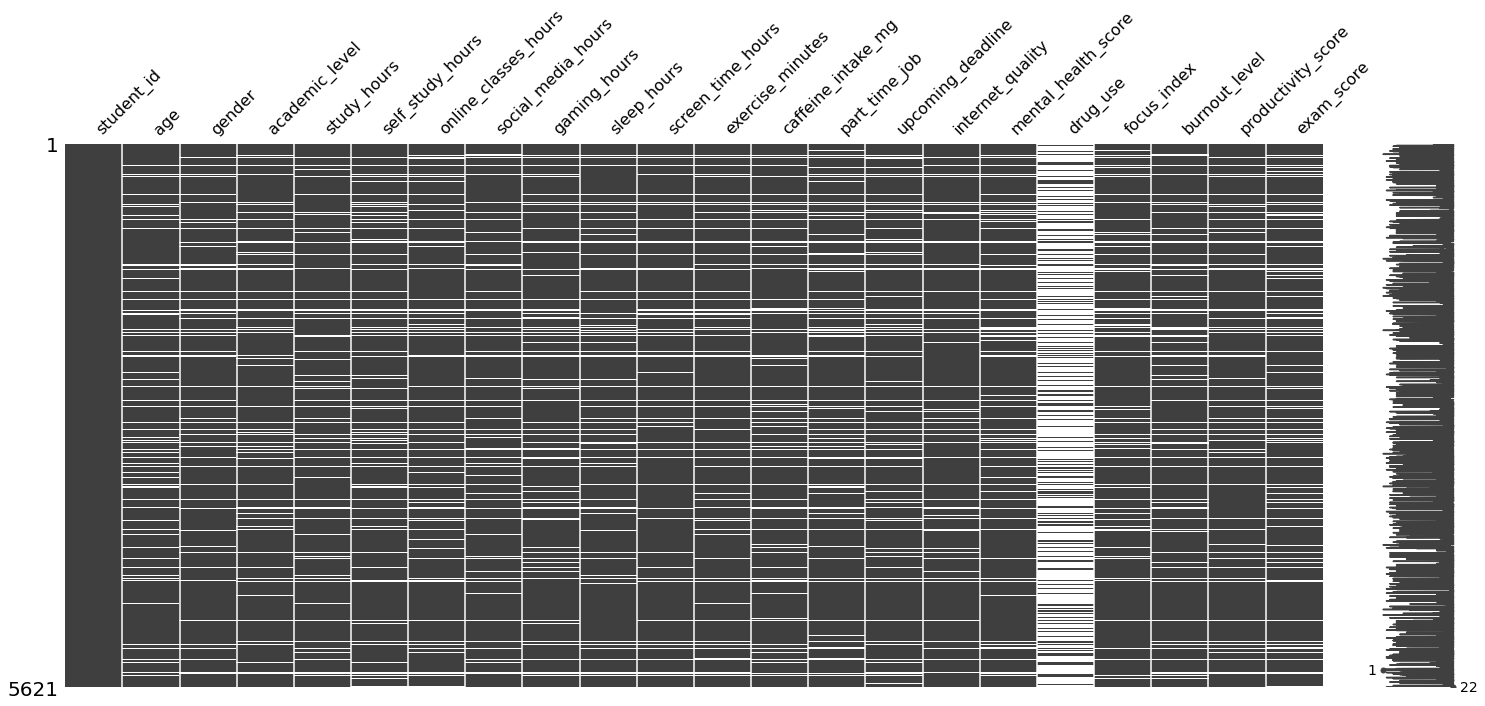

In [40]:
msn.matrix(df)


Como se puede observar, la columna de uso de drogas tiene muy pocos datos, por lo que imputarla seria inventar los datos. Por otro lado el ID del estudiante
no nos entrega información relevante, por lo que se eliminan las dos columnas

In [41]:
df = df.drop(columns=['student_id', 'drug_use'])

También se ve que hay filas que tienen tan pocos datos que imputarlos sería inventar casi toda la fila, por lo que decidí eliminarlas.

Y para ver cuales eliminar pense en elegir las filas con mayor datos faltantes viendo la distribución del porcentaje de faltantes por fila.

In [42]:
# Calcular porcentaje de faltantes por fila
missing_count = df.isnull().sum(axis=1)
missing_percent = (missing_count / df.shape[1]) * 100

print("=== Distribución del % de faltantes por fila ===")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  Percentil {p:2d}: {missing_percent.quantile(p/100):.1f}%")
print(f"  Máximo:       {missing_percent.max():.1f}%")

=== Distribución del % de faltantes por fila ===
  Percentil 25: 0.0%
  Percentil 50: 0.0%
  Percentil 75: 5.0%
  Percentil 90: 70.0%
  Percentil 95: 85.0%
  Percentil 99: 95.0%
  Máximo:       100.0%


El percentil 90 es de 70%, lo que indica que el 10% de las filas tiene más del 70% de datos faltantes.

Por lo que se eliminaron las filas con más del 70% de valores faltantes, eliminando 534 filas que poseian poca información la cual iba a ser inventada en su mayoria, lo que podia afectar el análisis

Filas a eliminar: 534


<AxesSubplot:>

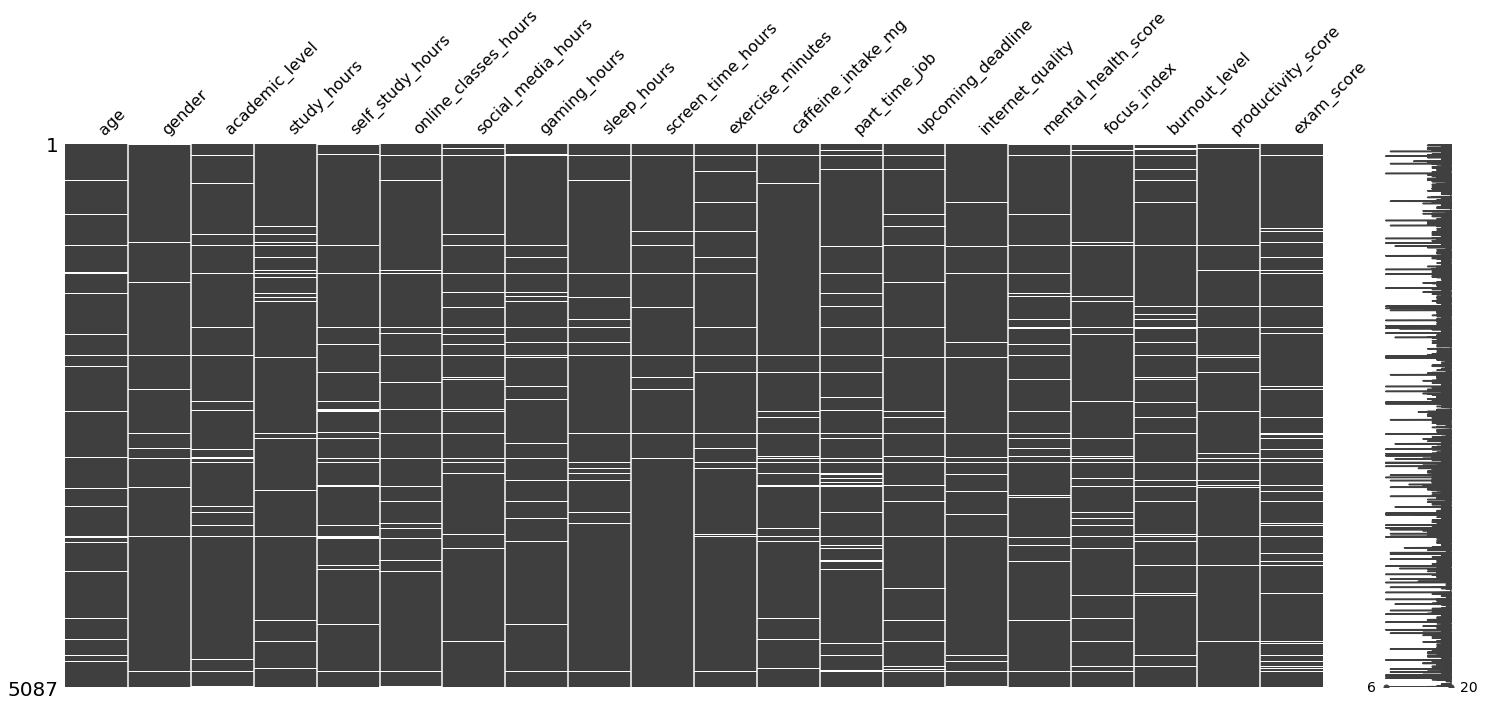

In [43]:
# Ver cuántas filas se van a eliminar
filas_vacias = df[missing_percent > 70]
print(f"Filas a eliminar: {len(filas_vacias)}")

# Eliminar filas con más del 70% de faltantes
df = df[missing_percent <= 70]
msn.matrix(df)

Las variables de estudio, sueño y pantalla están en horas. Sin embargo, el ejercicio está en minutos y tiene el texto `"min"` en algunos registros.
Por lo que se estandariza y se pasa a horas

In [44]:
# Limpiar exercise_minutes: quitar "min", convertir a número, pasar a horas
df['exercise_minutes'] = df['exercise_minutes'].astype(str).str.replace('min', '').str.strip()
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

# Convertir a horas y redondear a 2 decimales
df['exercise_hours'] = (df['exercise_minutes'] / 60).round(2)

# Eliminar la columna original
df = df.drop(columns=['exercise_minutes'])


### Variables categóricas

Las columnas de texto pueden tener inconsistencias espacios extra, mayúsculas mezcladas, etc. Se aplica `strip()` y `lower()` a todas.

In [45]:
# Estandarizar texto en todas las columnas object
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.lower() # al aplicar esto se convirtieron los NaN a nan

# Revertir los 'nan' string a np.nan
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].replace('nan', np.nan)

# Verificar algunas columnas
print(df['internet_quality'].value_counts(dropna=False))
print(df['part_time_job'].value_counts(dropna=False))
print(df['academic_level'].value_counts(dropna=False))
print(df['gender'].value_counts(dropna=False))

good       1706
average    1632
poor       1625
NaN         124
Name: internet_quality, dtype: int64
no     2420
yes    2409
NaN     258
Name: part_time_job, dtype: int64
postgraduate     1677
high school      1643
undergraduate    1605
NaN               162
Name: academic_level, dtype: int64
male      2168
female    2135
other      653
NaN        131
Name: gender, dtype: int64


Opte por imputar género aleatoriamente según su distribución (no se si existe), para mantener la misma proporción de hombres y mujeres en el dataset. 

Esto lo considere mejor que imputar con la moda, ya que no sesga la proporción del género. Sin embargo me dijeron que lo correcto sería con redes neuronales, pero no tengo pensado utilizar esta variable en el modelo asi que lo deje así.

In [46]:
mask_gender = df['gender'].isnull()
if mask_gender.sum() > 0:
    props = df['gender'].value_counts(normalize=True)
    df.loc[mask_gender, 'gender'] = np.random.choice(props.index, size=mask_gender.sum(), p=props.values)

print(f"NaN en gender después de imputación: {df['gender'].isnull().sum()}")
print(df['gender'].value_counts(dropna=False))

NaN en gender después de imputación: 0
male      2226
female    2194
other      667
Name: gender, dtype: int64


Para el resto de variables categóricas se imputa con la moda (valor más frecuente).

In [47]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().any():
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f"Columna '{col}': imputado con moda = {moda}")

# Verificar distribuciones
for col in categorical_cols:
    print(f"\n'{col}':", df[col].value_counts(dropna=False).to_dict())

Columna 'academic_level': imputado con moda = postgraduate
Columna 'part_time_job': imputado con moda = no
Columna 'internet_quality': imputado con moda = good

'gender': {'male': 2226, 'female': 2194, 'other': 667}

'academic_level': {'postgraduate': 1839, 'high school': 1643, 'undergraduate': 1605}

'part_time_job': {'no': 2678, 'yes': 2409}

'internet_quality': {'good': 1830, 'average': 1632, 'poor': 1625}


La variable `part_time_job` tiene valores `'yes'`/`'no'`. Por lo que podemos convertirla a binaria

In [48]:
df['part_time_job'] = df['part_time_job'].map({'yes': 1, 'no': 0})
print(df['part_time_job'].value_counts(dropna=False))

0    2678
1    2409
Name: part_time_job, dtype: int64


### Variables Numéricas

Primero empezamos con la variable de juego y ejercicio, ya que se puede ver de dos formas si juega o no (binaria), y cuánto juega (continua).

Si imputaba la variable binaria con la moda en ambos casos me daria que si realizan la acción, asi que prefiero imputar con 0 por la posibildad de que en estas columnas los NaN pueden significar que no contestaron porque no juegan, o solo no contestaron.

In [49]:
# Crear variable binaria preservando NaN donde gaming_hours es NaN
df['gaming_yes']   = np.where(df['gaming_hours'].isna(),  np.nan, (df['gaming_hours']  > 0).astype(float))
df['exercise_yes'] = np.where(df['exercise_hours'].isna(), np.nan, (df['exercise_hours'] > 0).astype(float))

# Ver la moda antes de decidir
print("Moda gaming_yes:  ", df['gaming_yes'].mode()[0])
print("Moda exercise_yes:", df['exercise_yes'].mode()[0])

# La moda es 1 en ambos casos, pero imputar con 1 sesgaría la distribución.
# Se imputa con 0: quien no contestó probablemente no realiza la actividad.
df['gaming_yes']   = df['gaming_yes'].fillna(0)
df['exercise_yes'] = df['exercise_yes'].fillna(0)

print("\nDespués de imputar:")
print("gaming_yes:  ", df['gaming_yes'].value_counts(dropna=False).to_dict())
print("exercise_yes:", df['exercise_yes'].value_counts(dropna=False).to_dict())

Moda gaming_yes:   1.0
Moda exercise_yes: 1.0

Después de imputar:
gaming_yes:   {1.0: 4353, 0.0: 734}
exercise_yes: {1.0: 4918, 0.0: 169}


Se imputa el resto de variables numéricas con la mediana ya que es más robusta que la media ante valores extremos.

In [50]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col != 'exam_score'] #se excluye exam_score para no imputar la variable objetivo

for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Columna '{col}': imputado con mediana = {df[col].median():.2f}")

# mental_health_score es una escala entera, se redondea para mantener coherencia
df['mental_health_score'] = df['mental_health_score'].round()

Columna 'age': imputado con mediana = 20.00
Columna 'study_hours': imputado con mediana = 4.53
Columna 'self_study_hours': imputado con mediana = 2.48
Columna 'online_classes_hours': imputado con mediana = 2.01
Columna 'social_media_hours': imputado con mediana = 2.99
Columna 'gaming_hours': imputado con mediana = 1.49
Columna 'sleep_hours': imputado con mediana = 7.01
Columna 'screen_time_hours': imputado con mediana = 6.95
Columna 'caffeine_intake_mg': imputado con mediana = 251.00
Columna 'upcoming_deadline': imputado con mediana = 1.00
Columna 'mental_health_score': imputado con mediana = 5.50
Columna 'focus_index': imputado con mediana = 29.41
Columna 'burnout_level': imputado con mediana = 45.70
Columna 'productivity_score': imputado con mediana = 36.95
Columna 'exercise_hours': imputado con mediana = 1.25


### Variable dependiente: `rindio`

Se eliminan las filas donde es NaN, estan filas contienen informacion en otras variables por eso decidi limpiar esta variable alfinal 

Se define como variable binaria para poder utilizar en las primeras preguntas, donde 1 es rindio si exam score es mayor a 1.0, eoc = 0

In [51]:
# Eliminar filas donde exam_score es NaN
df = df.dropna(subset=['exam_score'])

# Crear variable binaria
df['rindio'] = (df['exam_score'] > 1.0).astype(int)

print(f"Filas finales: {len(df)}")
print(df['rindio'].value_counts())
print(f"El {df['rindio'].mean()*100:.1f}% rindió el examen")

Filas finales: 4841
1    4408
0     433
Name: rindio, dtype: int64
El 91.1% rindió el examen


Total de NaN en el DataFrame: 0


<AxesSubplot:>

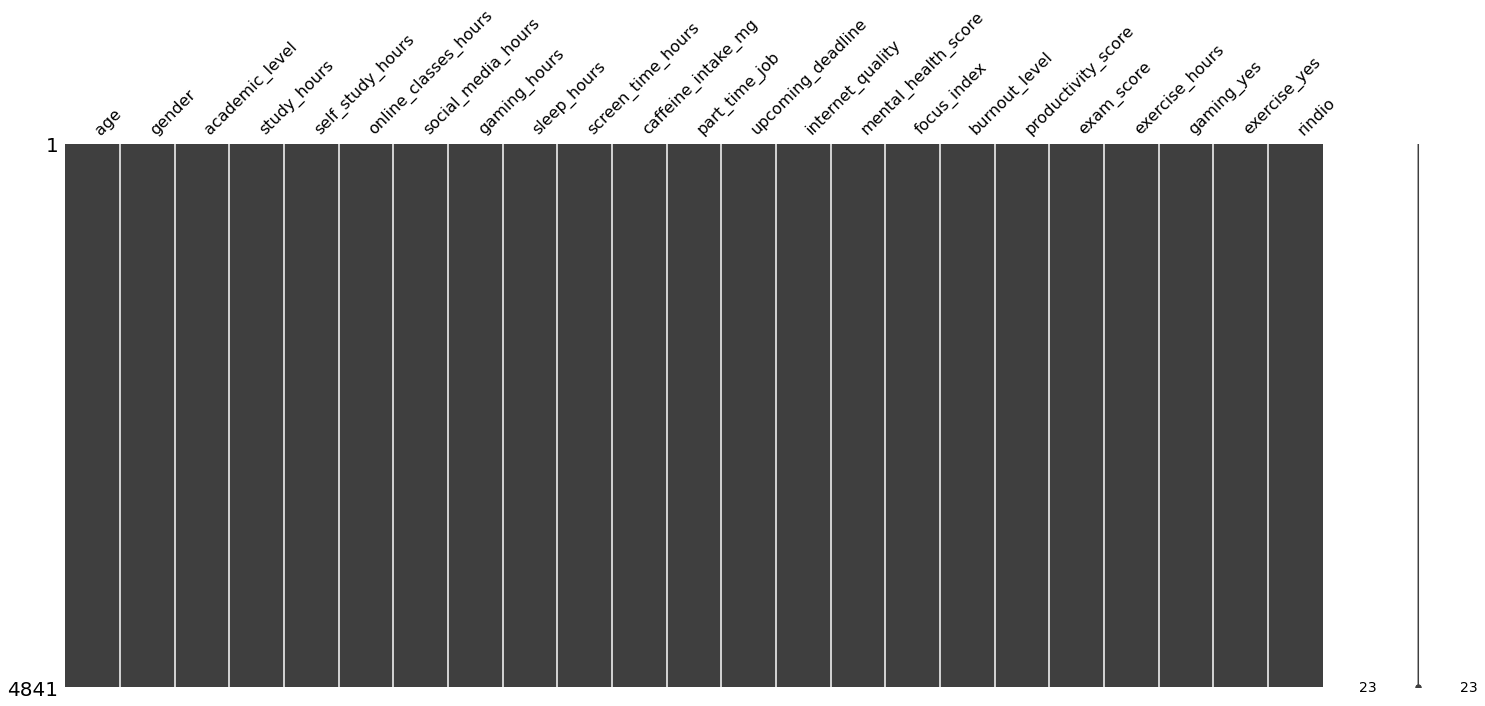

In [52]:
#Se confirma que no quedan valores faltantes antes de pasar al análisis.
print(f"Total de NaN en el DataFrame: {df.isnull().sum().sum()}")
msn.matrix(df)

## Análisis exploratorio

### Outliers

Se revisan las distribuciones de las variables principales para identificar valores atípicos.

Los outliers encontrados son realistas, si hay estudiantes que estudian 12 horas o pasan mucho tiempo en el celular, por lo que no se eliminan.

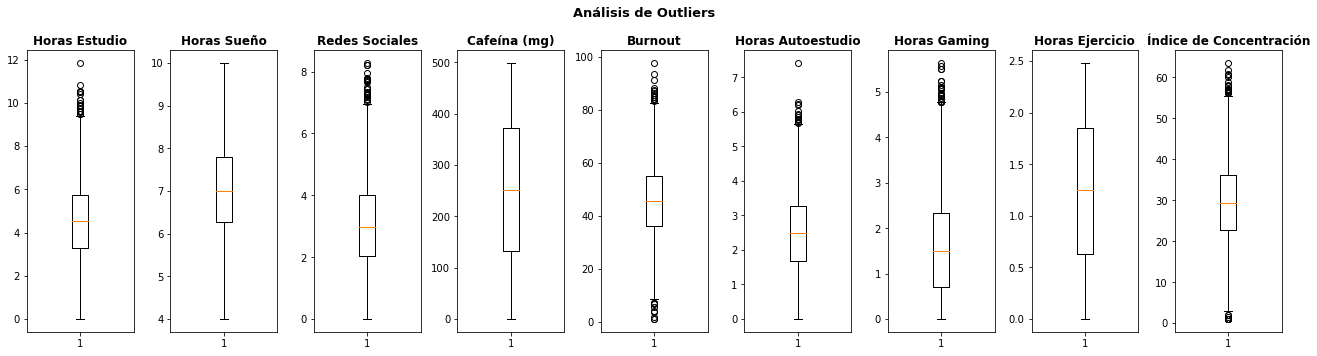

In [53]:
fig, axes = plt.subplots(1, 9, figsize=(18, 5))
fig.suptitle('Análisis de Outliers', fontsize=13, fontweight='bold')

variables_outlier = [
    ('study_hours',       'Horas Estudio'),
    ('sleep_hours',       'Horas Sueño'),
    ('social_media_hours','Redes Sociales'),
    ('caffeine_intake_mg','Cafeína (mg)'),
    ('burnout_level',     'Burnout'),
    ( 'self_study_hours',     'Horas Autoestudio'),
    ( 'gaming_hours',     'Horas Gaming'),
    ('exercise_hours',     'Horas Ejercicio'),
    ( 'focus_index',     'Índice de Concentración')
]

for ax, (var, lbl) in zip(axes, variables_outlier):
    ax.boxplot(df[var].dropna())
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout() 
plt.show()

### Matriz de correlación

Se analiza la correlación entre variables numéricas para tener una primera idea de qué podría ser relevante en los modelos.

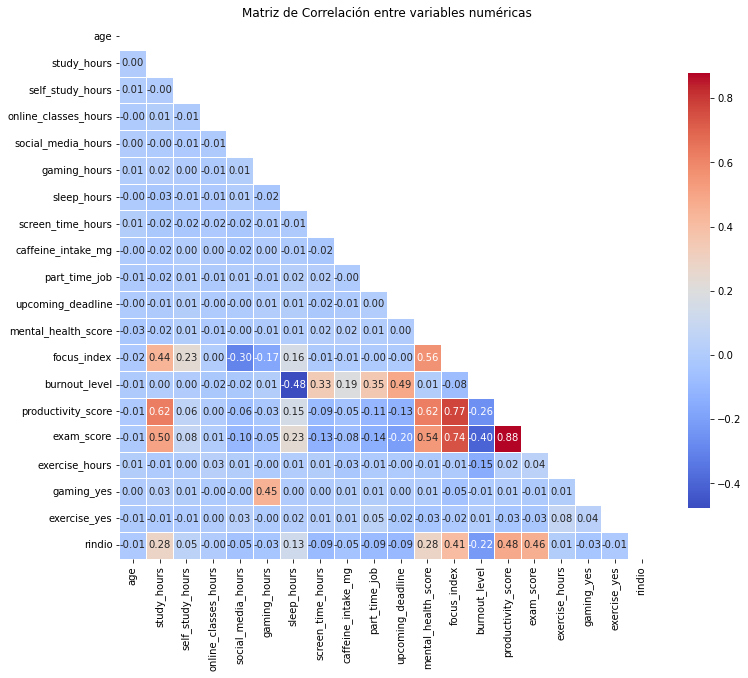

In [54]:
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre variables numéricas')
plt.show()

### Correlación con rindio ordenadas, para facilitar la lectura 

In [55]:
variables_interes = ['study_hours', 'sleep_hours', 'burnout_level', 'focus_index',
                      'social_media_hours', 'upcoming_deadline', 'mental_health_score',
                      'exercise_hours', 'gaming_hours', 'rindio']

corr_matrix = df[variables_interes].corr()
corr_con_rindio = corr_matrix['rindio'].drop('rindio').sort_values(ascending=False)
print("Correlación con rindio (ordenada):")
print(corr_con_rindio.round(3))

Correlación con rindio (ordenada):
focus_index            0.409
mental_health_score    0.283
study_hours            0.282
sleep_hours            0.131
exercise_hours         0.013
gaming_hours          -0.034
social_media_hours    -0.052
upcoming_deadline     -0.094
burnout_level         -0.224
Name: rindio, dtype: float64


Hay variables que me llaman la atención, por lo que visualizo su distribución rindió vrs no rindió

Se ve que los estudiantes que no rindieron el examen tienden a tener menores horas de estudio, peor salud mental y mayor nivel de burnout en comparación con quienes sí lo rindieron. Lo que ayuda a 

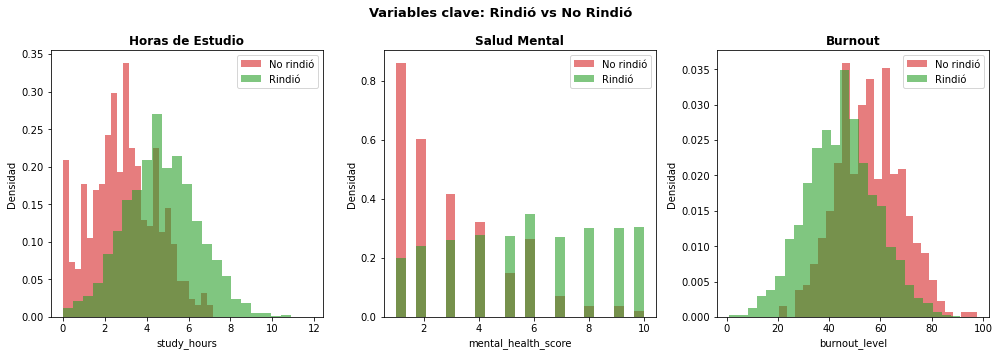

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Variables clave: Rindió vs No Rindió', fontsize=13, fontweight='bold')

for ax, var, lbl in zip(axes,
                         ['study_hours', 'mental_health_score', 'burnout_level'],
                         ['Horas de Estudio', 'Salud Mental', 'Burnout']):
    for val, label, color in [(0, 'No rindió', '#d62728'), (1, 'Rindió', '#2ca02c')]:
        ax.hist(df[df['rindio'] == val][var], bins=25, alpha=0.6,
                label=label, color=color, density=True)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()

---
## Preguntas 2, 3 y 4: Modelos de probabilidad para ver quien rendirá el examen

En base a lo que he visto en la vida, las personas que faltan a certámenes pueden ser porque han estudiado pocas horas, o estan muy agotados con muchas cosas (esto lo explica mejor el bournot que si tiene entrega pronto), o simplemente porque se sienten mal, no tienen confianza ni animo para estudiar lo cual creo que es una consecuencia de la salud mental.
Se sabe que mientras mas horas estudias, luego se cierto tiempo ya genera una fatiga por lo que se agrega una variable de estudio al cuadrado.
También si se estudia estresado, desmotivado o con problemas (quizas por menor salud mental) el estudio no rinde igual

La decisión de rendir un examen depende de dos dimensiones que interactúan: el **esfuerzo** del estudiante y su **estado mental**.

**Variables explicativas:**
- `study_hours`: más estudio, más incentivo y preparación para presentarse.
- `study_hours_sq`: el esfuerzo tiene rendimientos decrecientes.
- `mental_health_score`: la salud mental afecta la motivación y capacidad de afrontar el examen.
- `mhs_x_study` : el efecto del estudio depende del estado de ánimo.
- `burnout_level`: Un estudiante cansado evita evaluaciones

**Variable de control:**
- `C(academic_level)`: se usa porque estudiantes de distintos niveles tienen contextos muy diferentes, la exigencia o la madurez.

**Variables descartadas y por qué:**
- `sleep_hours` y `part_time_job`: su efecto opera a través del burnout, no es independiente.
- `social_media_hours` y `focus_index`: correlacionadas entre sí, el efecto no es robusto cuando se incluyen juntas.
- `gender` : no resulto significativas al controlar por las demás.
- `upcoming_deadline`: pierde significancia cuando burnout está en el modelo

In [57]:
# Término cuadrático: captura los rendimientos decrecientes del estudio
df['study_hours_sq'] = df['study_hours'] ** 2

# Interacción estudio × salud mental: el estudio rinde más con buena salud mental
df['mhs_x_study'] = df['mental_health_score'] * df['study_hours']


## Pregunta 2: Modelo de Probabilidad Lineal (MCO/OLS)

In [58]:
modelo_mco = smf.ols(
    'rindio ~ '
    'study_hours '           # esfuerzo base
    '+ study_hours_sq '      # rendimientos decrecientes
    '+ mental_health_score ' # bienestar mental
    '+ mhs_x_study '         # interacción estudio × salud mental
    '+ burnout_level '       # agotamiento
    '+ C(academic_level)',   # CONTROL: nivel académico
    data=df
).fit()

print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:                 rindio   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     278.2
Date:              lun., 20 abr. 2026   Prob (F-statistic):               0.00
Time:                        03:15:20   Log-Likelihood:                 20.582
No. Observations:                4841   AIC:                            -25.16
Df Residuals:                    4833   BIC:                             26.72
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

**Interpretación de coeficientes (MCO):**

Los coeficientes se interpretan directamente como cambios en la probabilidad de rendir:

- `study_hours` (+): cada hora adicional de estudio sube la probabilidad de rendir en ~0.20 puntos porcentuales.
- `study_hours_sq` (−): confirma los rendimientos decrecientes — el efecto del estudio se va frenando.
- `mental_health_score` (+): mejor salud mental aumenta la probabilidad de rendir.
- `mhs_x_study` (−): la interacción es negativa, lo que significa que el estudio ayuda relativamente más a quienes tienen peor salud mental. Quienes ya tienen buena salud mental casi seguro rinden de todas formas, y el estudio adicional aporta poco al margen.
- `burnout_level` (−): el agotamiento reduce la probabilidad de rendir, independiente del estudio.

In [59]:
modelo_mco = smf.ols(
    'rindio ~ '
    'focus_index '  
     ' + study_hours '         # esfuerzo base
    '+ study_hours_sq '      # rendimientos decrecientes
    '+ mental_health_score ' # bienestar mental
    '+ mhs_x_study '         # interacción estudio × salud mental
    '+ burnout_level '       # agotamiento
    '+ C(academic_level)',   # CONTROL: nivel académico
    data=df
).fit()

print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:                 rindio   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     271.0
Date:              lun., 20 abr. 2026   Prob (F-statistic):               0.00
Time:                        03:15:20   Log-Likelihood:                 98.181
No. Observations:                4841   AIC:                            -178.4
Df Residuals:                    4832   BIC:                            -120.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

## Pregunta 3: Modelo Probit

Se utilizaron las mismas variables independientes que en el modelo anterior, para poder comparar

In [60]:
modelo_probit = smf.probit(
    'rindio ~ '
    'study_hours '
    '+ study_hours_sq '
    '+ mental_health_score '
    '+ mhs_x_study '
    '+ burnout_level '
    '+ C(academic_level)',
    data=df
).fit()

print(modelo_probit.summary())

Optimization terminated successfully.
         Current function value: 0.163673
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                 rindio   No. Observations:                 4841
Model:                         Probit   Df Residuals:                     4833
Method:                           MLE   Df Model:                            7
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.4567
Time:                        03:15:20   Log-Likelihood:                -792.34
converged:                       True   LL-Null:                       -1458.4
Covariance Type:            nonrobust   LLR p-value:                1.969e-283
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.0304      0.273    

In [61]:
# Los efectos marginales sí se interpretan como cambios en probabilidad
efectos_probit = modelo_probit.get_margeff()
print(efectos_probit.summary())

       Probit Marginal Effects       
Dep. Variable:                 rindio
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
C(academic_level)[T.postgraduate]      0.0110      0.008      1.461      0.144      -0.004       0.026
C(academic_level)[T.undergraduate]     0.0247      0.008      3.122      0.002       0.009       0.040
study_hours                            0.0666      0.009      7.018      0.000       0.048       0.085
study_hours_sq                        -0.0019      0.001     -1.842      0.065      -0.004       0.000
mental_health_score                    0.0378      0.003     11.491      0.000       0.031       0.044
mhs_x_study                           -0.0018      0.001     -1.875      0.061      -0.004    7.96e-05
burnout_level           

**Interpretación (efectos marginales Probit):**

- `study_hours` (+0.067): una hora más de estudio sube la probabilidad de rendir en ~6.7 pp.
- `mental_health_score` (+0.038): un punto más de salud mental sube la probabilidad en ~3.8 pp.
- `burnout_level` (−0.005): un punto más de burnout la baja en ~0.5 pp.
- `study_hours_sq` y `mhs_x_study` son significativas solo al 10% en Probit. sea, la evidencia de que el estudio tenga rendimientos decrecientes y que ayude más a los que están mal de salud mental es débil en este modelo.

El modelo además avisa que un 18% de los casos se predicen perfectamente. Eso pasa porque hay combinaciones de variables (por ejemplo, muy pocas horas de estudio y burnout alto) que siempre llevan a "no va al examen". No es un problema, solo confirma que el modelo es bueno en esos extremos.

## Pregunta 4: Modelo Logit

In [62]:
modelo_logit = smf.logit(
    'rindio ~ '
    'study_hours '
    '+ study_hours_sq '
    '+ mental_health_score '
    '+ mhs_x_study '
    '+ burnout_level '
    '+ C(academic_level)',
    data=df
).fit()

print(modelo_logit.summary())

Optimization terminated successfully.
         Current function value: 0.163655
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 rindio   No. Observations:                 4841
Model:                          Logit   Df Residuals:                     4833
Method:                           MLE   Df Model:                            7
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.4567
Time:                        03:15:20   Log-Likelihood:                -792.25
converged:                       True   LL-Null:                       -1458.4
Covariance Type:            nonrobust   LLR p-value:                1.802e-283
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.3700      0.501   

In [63]:
efectos_logit = modelo_logit.get_margeff()
print(efectos_logit.summary())

        Logit Marginal Effects       
Dep. Variable:                 rindio
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
C(academic_level)[T.postgraduate]      0.0102      0.007      1.363      0.173      -0.004       0.025
C(academic_level)[T.undergraduate]     0.0252      0.008      3.196      0.001       0.010       0.041
study_hours                            0.0552      0.010      5.574      0.000       0.036       0.075
study_hours_sq                        -0.0010      0.001     -0.893      0.372      -0.003       0.001
mental_health_score                    0.0337      0.003     10.134      0.000       0.027       0.040
mhs_x_study                           -0.0003      0.001     -0.323      0.747      -0.002       0.002
burnout_level           

**Interpretación efectos marginales Logit:**

Logit da resultados muy parecidos a Probit, pero el cuadrado de las horas y la interacción dejan de ser significativos (p=0.372 y 0.747). Es decir, en Logit no podemos afirmar que el efecto del estudio sea decreciente ni que ayude más a los que tienen mala salud mental.

Esto nos dice que esos efectos no estables, lo más seguro es centrarse en las variables que sí se mantienen firmes en los tres modelos: horas de estudio, salud mental, burnout y el nivel pregrado.



# Pregunta 5: Comparación MCO, Probit y Logit

*Variables robustas a la especificación*

Las variables que se mantienen significativas y con el mismo signo en los tres modelos son:
Horas de estudio, Salud mental, Burnout, y Ser de pregrado 
Entonces podemos confiar en que realmente importan.

*Las variables que no son robustas:*

El `study_hours_sq` y `mhs_x_study`. Solo aparecen en MCO y marginalmente en Probit, pero desaparecen en Logit. 
Esto dice que el efecto del estudio en la decisión de rendir es mas bien lineal

*¿Por qué difieren los resultados?*

Cada modelo asume una forma funcional distinta para la probabilidad:
El MCO modela la probabilidad de forma lineal. Es el más simple pero puede dar valores fuera de [0,1].

El Probit y Logit son no lineales y respetan el rango [0,1]. Como los datos tienen muchos extremos (la mayoría rinde, pero una minoría no), el hecho de que no sea lineal importa, y por eso el ajuste mejora mucho en Probit/Logit.

## ¿Cuál es el más adecuado?

El Logit o Probit. El MCO no es apropiado para variables binarias.
porque garantizan probabilidades en [0,1]. 

Entre los dos, Logit es más estándar y sus efectos marginales son casi idénticos a los de Probit. Así que me quedo con Logit por la interpretación más directa de sus coeficientes (log-odds).

---
# Preguntas 6, 7 y 8:

La pregunta cambia: dado que asistió, que tan bien le va?. Aquí ya no es si siente que esta preparado, si no, si realmente lo esta.

Empezamos preparando los datos, se filtra solo a quienes rindieron y se redondea `exam_score` a entero para poder usarlos

In [64]:
# Filtrar solo quienes rindieron
df_rindio = df[df['rindio'] == 1].copy()

# Redondear exam_score a entero para Poisson
df_rindio['exam_score_int'] = df_rindio['exam_score'].round().astype(int)

print(f"Observaciones: {len(df_rindio)}")
print(df_rindio['exam_score_int'].describe())

Observaciones: 4408
count    4408.000000
mean       20.616606
std        11.296126
min         1.000000
25%        12.000000
50%        20.000000
75%        28.000000
max        64.000000
Name: exam_score_int, dtype: float64


### Planteamiento

Siempre hay alguien que estudia poco y le va bien, por eso la nota no solo refleja cuanto estudió, sino también, la capacidad cognitiva del estudiante en ese dia.

Se analiza primero la correlación con la nota para elegir variables.

Veremos la correlación de variables que se ven interesantes bajo esta hipótesis,

- **Por la preparación**: horas de estudio propia, ir a clases, horas de estudio.
- **Por la capacidad cognitiva**: nivel de burnout, concentracion, tambien hacer ejercicio y dormir bien deberia ayudar a la capacidad cognitiva.
- **Distracciones**: horas en redes sociales y en jugar, los cuales son cosas que tal vez afectan en la concentración o preparación.

In [65]:
variables_poisson = ['self_study_hours', 'online_classes_hours',
                     'sleep_hours', 'focus_index', 'exercise_yes',
                     'exercise_hours', 'social_media_hours',
                     'study_hours', 'gaming_hours', 'mental_health_score',
                     'burnout_level', 'exam_score_int']

corr_poisson = df_rindio[variables_poisson].corr()
corr_con_nota = corr_poisson['exam_score_int'].drop('exam_score_int').sort_values(ascending=False)
print("Correlación con exam_score_int (ordenada):")
print(corr_con_nota.round(3))

Correlación con exam_score_int (ordenada):
focus_index             0.707
mental_health_score     0.493
study_hours             0.454
sleep_hours             0.205
self_study_hours        0.070
exercise_hours          0.041
online_classes_hours    0.007
exercise_yes           -0.031
gaming_hours           -0.043
social_media_hours     -0.092
burnout_level          -0.357
Name: exam_score_int, dtype: float64


Los datos muestran que:

- `focus_index` (0.707) es un buen predictor.
- `mental_health_score` (0.493) y `burnout_level` (−0.357) también importan bastante.
- `study_hours` tiene correlación moderada-alta.
- horas de sueño, horas de autoestudio, ejercicio y gaming tienen correlaciones bajas.

Se quizo incluir `sleep_hours` y `self_study_hours`, pero:

- `sleep_hours` pierde significancia cuando `burnout_level` está en el modelo puede que su efecto opera a través del agotamiento.
- `self_study_hours` resultó con signo negativo (más autoestudio → peor nota), lo que puede ser quienes saben que les está yendo mal estudian más por su cuenta intentando recuperarse, pero igual es raro asi que prefiero no dejarlo.

## Pregunta 6: Modelo Poisson

Entonces,dado que el estudiante fue al examen, su nota depende de su capacidad cognitiva ese día (`focus_index`), su esfuerzo acumulado (`study_hours`), su bienestar mental (`mental_health_score`) y su nivel de agotamiento (`burnout_level`).

In [66]:
modelo_poisson = smf.poisson(
    'exam_score_int ~ '
    'focus_index '            # predictor dominante: concentración
    '+ study_hours '          # esfuerzo acumulado
    '+ mental_health_score '  # bienestar mental
    '+ burnout_level '        # agotamiento reduce el desempeño
    '+ C(academic_level)',    # CONTROL: nivel académico
    data=df_rindio
).fit()

print(modelo_poisson.summary())

Optimization terminated successfully.
         Current function value: 3.358502
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4408
Model:                        Poisson   Df Residuals:                     4401
Method:                           MLE   Df Model:                            6
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.4021
Time:                        03:15:21   Log-Likelihood:                -14804.
converged:                       True   LL-Null:                       -24760.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              2.0418      0.018    

In [67]:
print(modelo_poisson.get_margeff().summary())

       Poisson Marginal Effects      
Dep. Variable:         exam_score_int
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
C(academic_level)[T.postgraduate]     -0.1244      0.166     -0.748      0.455      -0.451       0.202
C(academic_level)[T.undergraduate]    -0.1079      0.170     -0.635      0.525      -0.441       0.225
focus_index                            0.4405      0.010     42.578      0.000       0.420       0.461
study_hours                            2.2101      0.046     47.807      0.000       2.119       2.301
mental_health_score                    1.4536      0.032     44.820      0.000       1.390       1.517
burnout_level                         -0.3166      0.005    -61.794      0.000      -0.327      -0.307


**Interpretación  de los efectos marginales Poisson:**

- `focus_index`: un punto más de concentración sube la nota esperada en ~0.44 puntos.
- `study_hours`: una hora más de estudio sube la nota en ~2.2 puntos.
- `mental_health_score`: un punto más de salud mental sube la nota en ~1.45 puntos.
- `burnout_level`: un punto más de burnout baja la nota en ~0.32 puntos.

El nivel académico deja de ser significativo. Una vez que controlas por concentración, estudio, salud mental y burnout, da igual si eres de secundaria, pregrado o postgrado. Lo que importa son esas variables.

El pseudo R² es 0.402, lo que significa que el modelo explica el 40% de la variación en la nota. 

### Pregunta 7: Test de sobredispersión y estimación de alpha

Determine si existe sobre dispersión en la data y posible valor óptimo de alpha para un modelo Binomial Negativa.

Poisson asume que la media y la varianza son iguales. Si la varianza es mucho mayor que la media, hay sobredispersión y el Binomial Negativo seria más apropiado.

In [68]:
# ratio varianza/media 
media    = df_rindio['exam_score_int'].mean()
varianza = df_rindio['exam_score_int'].var()
ratio    = varianza / media

print("=== Test de sobredispersión ===")
print(f"Media:    {media:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Ratio varianza/media: {ratio:.2f}")


=== Test de sobredispersión ===
Media:    20.62
Varianza: 127.60
Ratio varianza/media: 6.19


Hay sobredispersión ya que el ratio es mayor a 1, La varianza de la nota es seis veces mayor que la media entonces el modelo poisson subestima la variabilidad real y se justifica usar el Binomial Negativo.

In [69]:
# ratio de Pearson chi2 del modelo Poisson
# Un valor > 1 confirma sobredispersión (varianza real > varianza Poisson)
# Calcular Pearson chi2 manualmente desde los residuos
residuals = modelo_poisson.resid_pearson
pearson_chi2 = (residuals ** 2).sum()
df_residual   = modelo_poisson.df_resid
ratio_pearson = pearson_chi2 / df_residual

print(f"Pearson chi2:  {pearson_chi2:.2f}")
print(f"Df Residuals:  {df_residual}")
print(f"Ratio chi2/Df: {ratio_pearson:.2f}")

Pearson chi2:  8382.52
Df Residuals:  4401.0
Ratio chi2/Df: 1.90


Ya que en ambas pruebas confirman la sobredispersión. Algunos estudiantes sacan notas muy bajas y otros muy altas, aunque tengan valores similares en las variables explicativas.


estimamos el Alpha

In [70]:
# estimación auxiliar de alpha 
# aux = [(y - lambda)^2 - lambda] / lambda
# Regresión de aux sobre lambda sin constante → el coeficiente es alpha
lambda_hat = modelo_poisson.predict()
y          = df_rindio['exam_score_int']
aux        = ((y - lambda_hat)**2 - lambda_hat) / lambda_hat

aux_df       = pd.DataFrame({'aux': aux, 'lambda_hat': lambda_hat})
modelo_alpha = smf.ols('aux ~ lambda_hat - 1', data=aux_df).fit()

print(" Estimación auxiliar de alpha")
print(f"Alpha estimado: {modelo_alpha.params['lambda_hat']:.4f}")

# El valor de alpha se usará como referencia para el modelo Binomial Negativo, que ajusta la varianza real.

 Estimación auxiliar de alpha
Alpha estimado: 0.0324


El parámetro alpha es significativamente distinto de cero. Por lo tanto, el modelo apropiado es el Binomial Negativo.

### Pregunta 8: Modelo Binomial Negativo

El Binomial Negativo extiende el Poisson permitiendo que la varianza sea mayor que la media, a través del parámetro `alpha`. Se usa exactamente la misma especificación que el Poisson para que la comparación sea justa.

In [71]:
modelo_negbin = smf.negativebinomial(
    'exam_score_int ~ '
    'focus_index '
    '+ study_hours '
    '+ mental_health_score '
    '+ burnout_level '
    '+ C(academic_level)',
    data=df_rindio
).fit()

print(modelo_negbin.summary())

Optimization terminated successfully.
         Current function value: 3.245636
         Iterations: 21
         Function evaluations: 42
         Gradient evaluations: 33
                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 4408
Model:               NegativeBinomial   Df Residuals:                     4401
Method:                           MLE   Df Model:                            6
Date:              lun., 20 abr. 2026   Pseudo R-squ.:                  0.1506
Time:                        03:15:21   Log-Likelihood:                -14307.
converged:                       True   LL-Null:                       -16843.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [72]:
print(modelo_negbin.get_margeff().summary())

  NegativeBinomial Marginal Effects  
Dep. Variable:         exam_score_int
Method:                          dydx
At:                           overall
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
C(academic_level)[T.postgraduate]     -0.1669      0.243     -0.688      0.491      -0.643       0.309
C(academic_level)[T.undergraduate]    -0.0953      0.248     -0.385      0.700      -0.580       0.390
focus_index                            0.4870      0.016     31.298      0.000       0.456       0.517
study_hours                            2.4125      0.070     34.536      0.000       2.276       2.549
mental_health_score                    1.5285      0.047     32.356      0.000       1.436       1.621
burnout_level                         -0.3456      0.008    -43.900      0.000      -0.361      -0.330


Al ajustar el Binomial Negativo con las mismas variables, los coeficientes son muy parecidos a los del Poisson.
Lo que sí cambia es que los errores estándar son más grandes. 

### Pregunta 9: Comparación Poisson vs Binomial Negativa

*Variables robustas*

Las mismas: concentración, horas de estudio, salud mental y burnout. En ambos modelos son significativas y con el mismo signo.

*¿Por qué difieren los resultados?*

En esencia, no difieren mucho en los coeficientes puntuales, pero sí en la incertidumbre. 
El Poisson subestima los errores estándar, cuando en realidad hay mucha variabilidad entre estudiantes que no está siendo capturada por las variables. 
El Binomial Negativo reconoce esa variabilidad extra, por lo que los errores estandar son mayores.

*¿Cuál es más adecuado?*

El Binomial Negativo. La sobredispersión es clara (varianza 6 veces la media) y el parámetro alpha es significativo (0.047, p<0.001). 

Ignorar esto y usar Poisson subestimaría los errores estándar, dando una falsa precisión. Aunque los coeficientes puntuales son similares, el NegBin reporta errores más realistas y es el modelo correcto.